### Lab 01b: Binary Linear Classifier

In this lab you will try making a binary linear classifier using the [Palmer Penguins dataset](https://allisonhorst.github.io/palmerpenguins/).

In [2]:
import sklearn
from palmerpenguins import load_penguins
from mlxtend.plotting import plot_decision_regions

The dataset is loaded as a [Pandas dataframe](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html).  

In [3]:
df = load_penguins()
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


For simplicity we will drop any rows with missing values (encoded as NaNs).

In [4]:
df.dropna(inplace=True)
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


Let's select just the Adelie and Chinstrap penguins.

In [5]:
df = df[(df['species']=='Adelie')|(df['species']=='Chinstrap')]

Now we will grab the flipper length and bill length to be the features (stored in ``X``) and the species as the labels (stored in ``y``).

In [6]:
X = df[['flipper_length_mm','bill_length_mm']].values
y = df['species'].map({'Adelie':0,'Chinstrap':1}).values

## Exercises

1. Fit a binary linear classifier using scikit-learn (see ``sklearn.linear_model.LogisticRegression``).

Plot the resulting classifier using ``plot_decision_regions(X, y, clf=model)``.


<Axes: >

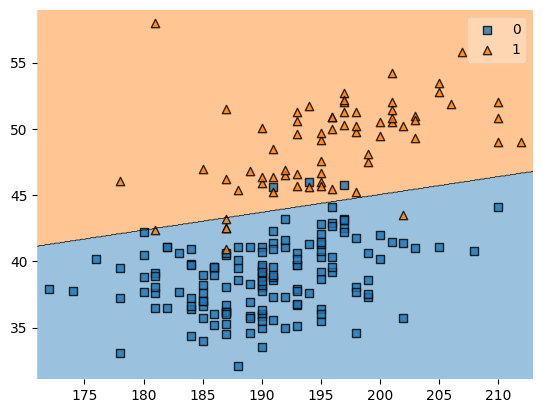

In [7]:
import sklearn.linear_model
model = sklearn.linear_model.LogisticRegression()
model.fit(X,y)
plot_decision_regions(X, y, clf=model)

2. Print out the coefficients of the line (``model.coef_``).  Interpret these values (in terms of the direction of the line and also what they tell us about how the classifier operates).

In [8]:
model.coef_

array([[-0.15845623,  1.17936568]])

The first coefficient (-0.158) is the y-intercept for the line, and the second coefficient (1.179) is the slope for the line. They help represent the decision boundary between the two classes of penguins, where if the given flipper length and bill length pair falls above the line, it is predicted 1, and otherwise it is predicted 0.

3. Calculate and print out the accuracy of the classifier using the `.score` function.  Interpret this value.

In [12]:
model.score(X, y)

0.9579439252336449

4. Try different combinations of features and print out the accuracy for each one.  Interpret your results.

In [11]:
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='object')

In [14]:
X = df[['body_mass_g']].values
model.fit(X, y)
model.score(X, y)

0.6822429906542056

In [18]:
X = df[['body_mass_g', 'flipper_length_mm']].values
model.fit(X, y)
model.score(X, y)

0.7383177570093458

In [16]:
X = df[['body_mass_g', 'flipper_length_mm', 'bill_length_mm']].values
model.fit(X, y)
model.score(X, y)

0.985981308411215

In [17]:
X = df[['body_mass_g', 'flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']].values
model.fit(X, y)
model.score(X, y)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9906542056074766

The more features you add to the model, the better the accuracy becomes. We reach nearly a perfect training accuracy when given the four variables above, which could be a sign of overfitting.